# Results walkthrough: does order-book imbalance predict short-horizon price moves?

This notebook reproduces the headline numbers from `docs/methodology.md` directly from the committed artifacts (`reports/research_results.csv`, `reports/*_BTC.json`) so a reader can inspect them without re-running the full pipeline.

**Research/education only — not investment advice.**

In [1]:
import json
from pathlib import Path

import polars as pl

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results = pl.read_csv(ROOT / "reports" / "research_results.csv")
results.shape

(75, 21)

## 1. Headline table: top-of-book imbalance vs. forward mid-price return

Held-out test split only (chronological 70/30 split — these numbers were never used to pick the net-of-cost threshold, which was calibrated on the train split).

In [2]:
tob = results.filter(pl.col("feature") == "tob_imbalance").sort(["symbol", "horizon_ms"])
tob.select(
    ["symbol", "horizon_ms", "n", "pearson", "spearman", "hit_rate", "hit_rate_p", "net_mean_bps", "net_pct_positive"]
)

symbol,horizon_ms,n,pearson,spearman,hit_rate,hit_rate_p,net_mean_bps,net_pct_positive
str,i64,i64,f64,f64,f64,f64,f64,f64
"""BTC""",100,873,0.363064,0.469773,0.802158,3.6853e-25,-8.501658,0.0
"""BTC""",500,873,0.363064,0.469773,0.802158,3.6853e-25,-8.501658,0.0
"""BTC""",1000,873,0.363064,0.469773,0.802158,3.6853e-25,-8.501658,0.0
"""BTC""",5000,873,0.363064,0.469773,0.802158,3.6853e-25,-8.501658,0.0
"""BTC""",10000,872,0.33582,0.409415,0.728972,7.9634e-22,-8.388462,0.0
…,…,…,…,…,…,…,…,…
"""SOL""",100,873,0.328505,0.383249,0.725212,1.1380e-17,-8.463326,0.0
"""SOL""",500,873,0.328505,0.383249,0.725212,1.1380e-17,-8.463326,0.0
"""SOL""",1000,873,0.328505,0.383249,0.725212,1.1380e-17,-8.463326,0.0


## 2. The native-cadence finding

Hyperliquid's `l2Book` channel pushes on a median ~5.4s cadence (empirically measured — see `docs/api_notes.md` §1 and `docs/methodology.md` §2). That means the 100ms/500ms/1s/5s columns above are, for the overwhelming majority of rows, measuring the *same* next-book-update observation — not independent points on a decay curve. Only the jump to 10s is a genuinely distinct measurement. The cell below shows this directly: within a single symbol, the correlation is essentially flat until 10s.

In [3]:
tob.filter(pl.col("symbol") == "BTC").select(["horizon_ms", "pearson", "spearman"])

horizon_ms,pearson,spearman
i64,f64,f64
100,0.363064,0.469773
500,0.363064,0.469773
1000,0.363064,0.469773
5000,0.363064,0.469773
10000,0.33582,0.409415


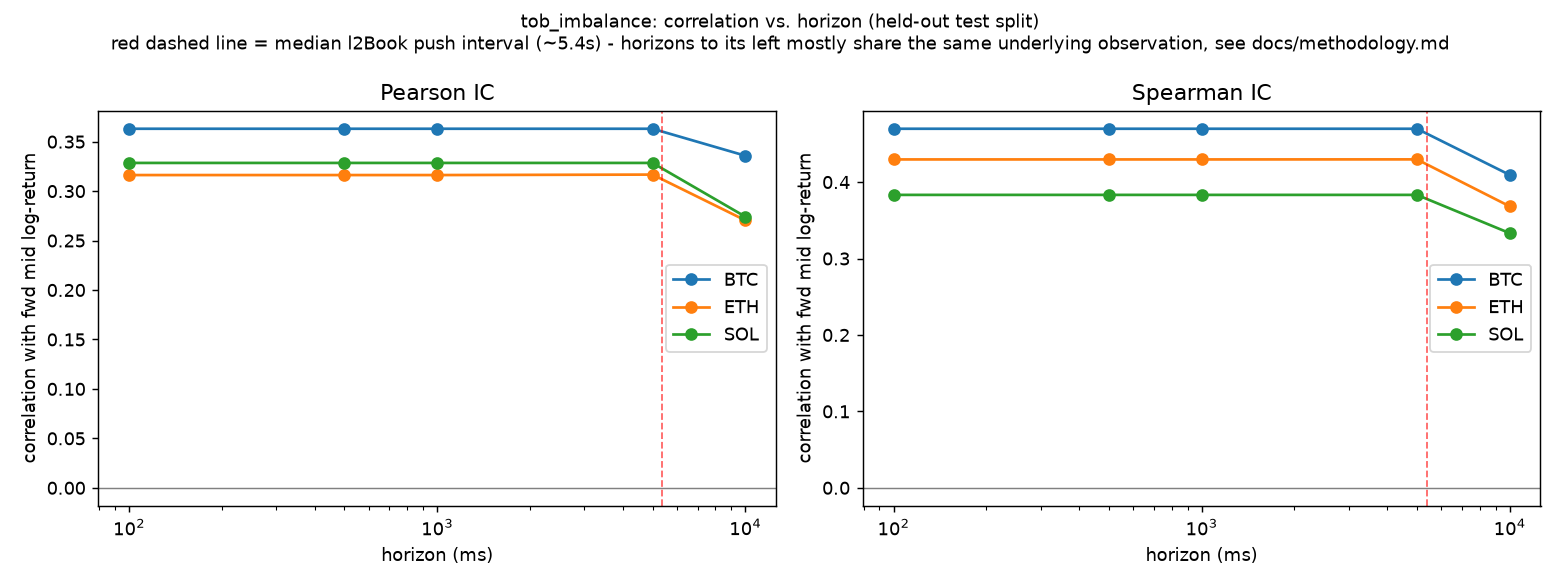

In [4]:
from IPython.display import Image

Image(filename=str(ROOT / "docs" / "assets" / "imbalance_decay.png"))

## 3. Net-of-cost check: does the signal survive real trading costs?

Entering in the imbalance direction whenever `|tob_imbalance|` exceeds its train-split 75th-percentile threshold, holding to the label horizon, and subtracting a round-trip cost of spread + 2x taker fee (~9.16bps at Hyperliquid's base 4.5bps taker tier).

In [5]:
tob.select(["symbol", "horizon_ms", "net_cost_threshold", "net_n", "net_mean_bps", "net_pct_positive", "net_p"])

symbol,horizon_ms,net_cost_threshold,net_n,net_mean_bps,net_pct_positive,net_p
str,i64,f64,i64,f64,f64,f64
"""BTC""",100,0.957512,179,-8.501658,0.0,2.0787e-160
"""BTC""",500,0.957512,179,-8.501658,0.0,2.0787e-160
"""BTC""",1000,0.957512,179,-8.501658,0.0,2.0787e-160
"""BTC""",5000,0.957512,179,-8.501658,0.0,2.0787e-160
"""BTC""",10000,0.957512,178,-8.388462,0.0,1.4353e-144
…,…,…,…,…,…,…
"""SOL""",100,0.978099,153,-8.463326,0.0,1.6416e-134
"""SOL""",500,0.978099,153,-8.463326,0.0,1.6416e-134
"""SOL""",1000,0.978099,153,-8.463326,0.0,1.6416e-134


Mean net return is negative across every symbol and horizon in this sample — the raw directional edge is real (see the IC/hit-rate table above) but its typical magnitude never clears the round-trip taker cost. See `docs/methodology.md` §6-7 for the full discussion, including what would need to be true (maker-side execution, rarer/larger imbalance events, fee discounts) for this to look different.

## 4. Backtest reports: naive vs. inventory-aware market maker

Both strategies run against the same real collected BTC data (`scripts/run_backtest.py`).

In [6]:
for name in ("naive_mm", "inventory_mm"):
    with open(ROOT / "reports" / f"{name}_BTC.json") as f:
        summary = json.load(f)
    print(f"--- {name} ---")
    for k, v in summary.items():
        print(f"  {k}: {v}")
    print()

--- naive_mm ---
  strategy: naive_mm
  symbol: BTC
  n_fills: 88
  turnover_usd: 40379.36077000001
  realized_pnl: 15.033625394609924
  fees_paid: 6.056904115499999
  funding_paid: -0.1959604794792475
  starting_cash: 100000
  final_equity: 99987.11885886344
  total_return_pct: -0.012881141136555918
  sharpe: -21.08679048347715
  max_drawdown_pct: -0.03936712941118995
  var_95: 0.5956659019167992
  es_95: 1.4405740643058844

--- inventory_mm ---
  strategy: inventory_mm
  symbol: BTC
  n_fills: 81
  turnover_usd: 40828.406275
  realized_pnl: 17.92634499999958
  fees_paid: 6.124260941249998
  funding_paid: -0.09900928607928576
  starting_cash: 100000
  final_equity: 100005.4844608455
  total_return_pct: 0.005484460845495143
  sharpe: 12.724554392712134
  max_drawdown_pct: -0.01863061757229195
  var_95: 0.32566637237905527
  es_95: 0.9469284320947613



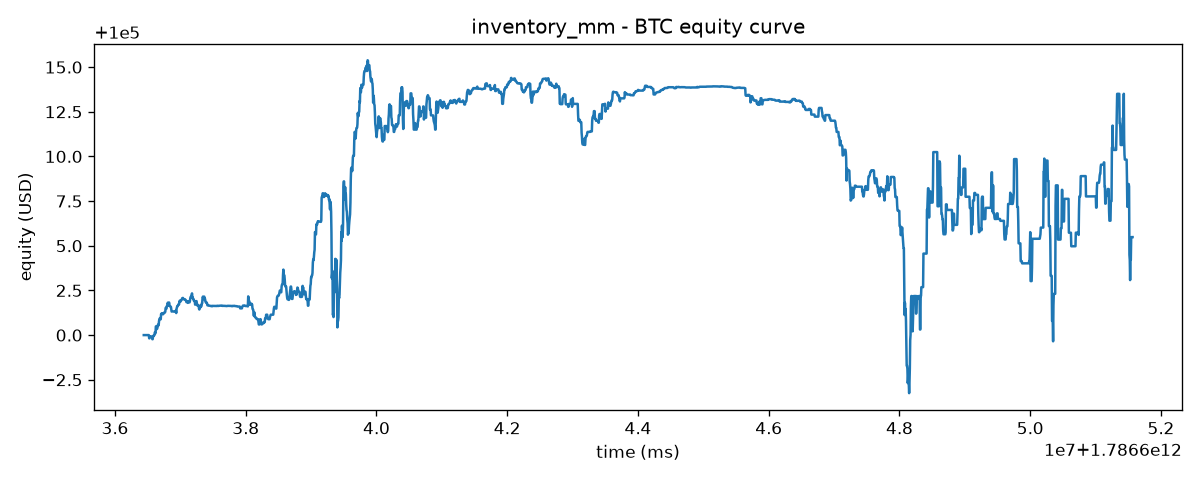

In [7]:
Image(filename=str(ROOT / "reports" / "inventory_mm_BTC_equity.png"))

## 5. Conclusion

Order-book imbalance is a real, statistically robust predictor of the *direction* of the next Hyperliquid order-book update, consistent across BTC/ETH/SOL and across top-of-book and depth-weighted variants. But the typical magnitude of that edge is small enough that it does not survive Hyperliquid's realistic round-trip taker cost for a naive threshold-crossing strategy on this sample — net returns are negative in effectively 100% of signal events tested.

This is reported as a rigorous, disclosed outcome rather than reframed to look more positive than the data supports — see `docs/methodology.md` for the full validation discipline (chronological split, HAC standard errors, multiple-comparison disclosure) and limitations behind these numbers.